# ***Predicting Firm-Level Loss Behaviour and Corporate Income Tax (CIT) Revenue Risk in Kenya***


### Authors

Brian Kahiu, John Karanja, Cyrus Mutuku, Catherine Gachiri, Fredrick Nzeve, Grace Kinyanjui, Jeremy Onsongo


### 1.0 Business Understanding

### Background Information

The Kenya Revenue Authority (KRA), established in 1995, is responsible for collecting all national government revenue. Corporate Income Tax (CIT) is levied at 30% for resident companies and non-residents under the Income Tax Act, with sector-specific incentives available through Special Economic Zones (SEZs), Capital Deductions and Export Processing Zones (EPZs).

Companies must file annual CIT returns (ITC2 form) electronically via the iTax platform within six months of their accounting year-end, supported by valid electronic Tax Invoice Management System (eTIMS) invoices. Taxable income is calculated as gross income less allowable business expenses. A company is considered tax resident if incorporated in Kenya or if management and control is exercised locally.

### Business Problem Definition

Kenya has persistently failed to meet Corporate Income Tax (CIT) revenue targets. The high prevalence of firms reporting losses significantly erodes the effective tax base, creating fiscal deficit. The central problem is the lack of an empirical, data-driven framework for:

1. Identifying which firm-level characteristics are associated with loss reporting.
2. Proactively identifying high-risk firms and sectors.
3. Assessing how firm-level loss behavior translates into systemic CIT revenue risk.

### Our Solution

An automated risk scoring system that:

1. Processes firm-level CIT return data using the methodology outlined in the project proposal.
2. Employs an iterative modeling approach, beginning with interpretable logistic regression as a primary benchmark.
3. Applies machine learning to identify high-risk loss-reporting firms for targeted compliance.

### Project Objectives

***General Objective***

To predict the probability of a firm reporting a loss

***Specific Objectives***

1. To empirically identify firm-level characteristics associated with loss reporting in CIT returns.
2. To develop a supervised predictive model estimating the probability of a firm reporting a loss.
3. To assess the concentration and distribution of loss behavior across sectors and firm groups.
4. To translate firm-level loss probabilities into insights on aggregate CIT revenue risk.

### Methodology

This project follows the Cross-Industry Standard Process for Data Mining (CRISP-DM) to ensure a structured, transparent, and policy-relevant analytics workflow.

### Business Understanding

Stakeholder needs were identified, the business problem was defined, and success metrics were established to align analytical outputs with compliance and fiscal objectives.

### Data Understanding

Corporate Income Tax return data for 2024 were explored to assess structure, data quality, and preliminary patterns in loss-reporting behavior across firms and sectors.

### Data Preparation

Raw accounting variables were transformed into financial ratios, with outlier treatment and feature creation applied to improve data quality and model stability.

### Modeling

A baseline Logistic Regression model was developed as an interpretable benchmark, followed by an optimized XGBoost model using systematic hyperparameter tuning.

### Evaluation
Model performance was assessed using ROC-AUC, precision, recall, and F1-score, alongside business impact analysis and SHAP-based explainability.

### Deployment
A high-level implementation roadmap was defined, including model packaging, integration into audit selection workflows, and monitoring considerations.

### Success Metrics
### Technical Metrics

Model performance assessed using AUC-ROC, precision, recall, and F1-score.
Validation follows a time-based split to reflect real-world forecasting conditions.

### Business Metrics

-Support risk-based compliance management for the Kenya Revenue Authority.
-Provide clearer understanding of structural weaknesses in the CIT base for the National Treasury.
-Inform policy discussions on capital allowances, financing structures, and related-party transactions.

### Primary Stakeholders

1. KRA Compliance Directors

***Problem:*** Manual audit selection misses high-risk loss-reporting firms

***Need:*** Prioritize firms with highest evasion probability for investigation

***Business Value:*** Improved audit efficiency and revenue recovery

2. Tax Policy Analysts at National Treasury

***Problem:*** Revenue forecasting uncertainty due to loss declaration patterns

***Need:*** Data-driven risk assessment for fiscal planning and budgeting

***Business Value:*** Improved accuracy in CIT revenue projections

3. Field Tax Officers

***Problem:*** Wasted time on low-risk audits with minimal revenue recovery

***Need:*** Focus investigations on firms with highest probability of tax avoidance

***Business Value:*** Higher productivity and improved targeting outcomes

### 2.0 Data Description
The analysis uses 2024 Corporate Income Tax return data containing 313,870 firm-year observations across 61 variables (47 numeric, 14 categorical). The dataset includes financial data, sector classifications, and firm characteristics from administrative filings.

### 3.0 Modeling Scope Definition

Validity: Retain only active businesses with positive turnover

Target: Flag firms as "Risk" (is_loss = 1) if Profit Before Tax is negative

Sector Standardization: Clean sector names and consolidate rare sectors




### 1.0 Import the necessary libraries

We import the key libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Machine learning Preprocessing & Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, precision_recall_curve, brier_score_loss, log_loss
)

# Model interpretability
import shap

# Model saving
import joblib

# System utilities
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


### 2.0 Data loading and Initial Checks
Here, we imported the raw tax data and examined its basic structure.

In [6]:
df = pd.read_csv("CIT2024.csv", low_memory=False)
df.shape

(313870, 61)

In [9]:
df.info()
print(df.dtypes.value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313870 entries, 0 to 313869
Data columns (total 61 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   unique_id                      313870 non-null  float64
 1   business_type                  313870 non-null  object 
 2   business_subtype               310874 non-null  object 
 3   epz_effective_dt               149 non-null     object 
 4   period_from                    313870 non-null  object 
 5   period_to                      313870 non-null  object 
 6   filing_date                    313870 non-null  object 
 7   is_nil_return                  313870 non-null  object 
 8   return_type                    313870 non-null  object 
 9   assmt_type                     313870 non-null  object 
 10  eff_dt_com_activity            85 non-null      object 
 11  sector                         313862 non-null  object 
 12  division_                     

In [4]:
df.head(5)

,unique_id,business_type,business_subtype,epz_effective_dt,period_from,period_to,filing_date,is_nil_return,return_type,assmt_type,...,prof_loss_tax_div_bal_st,empexp__salary_wages,init_plant_mach_allow,init_indu_buld_allow,cap_allw_indu_buld,wear_tear_dedc_rbm,wear_tear_dedc_slm,deduct_agri_land,tot_allow_deductions,avg_no_of_employees
0,1.210000e+09,Company,Private Company,NaN,1/1/2024,31/12/2024,27/06/2025,N,Original,S,...,8191.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,1.210001e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,27/06/2025,Y,Original,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,27/05/2025,N,Original,S,...,151384.13,250000.0,0.0,0.0,0.0,1853.1,0.0,0.0,1853.1,NaN
3,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,20/05/2025,Y,Original,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,29/06/2025,N,Original,S,...,114704.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


### 2.1 Missing Values and Duplicate Check

- We checked for missing values and duplicates 

In [17]:
# 1. Duplicate check
print("Duplicated Rows",df.duplicated().sum())

# 2. Missing values check
df.isnull().mean().mul(100).round(3).sort_values(ascending=False)
print("Top 10 columns with missing values in percentage (%)")
print(df.isnull().mean().mul(100).round(3).sort_values(ascending=False).head(10))


Duplicated Rows 3011
Top 10 columns with missing values in percentage (%)
eff_dt_com_activity             99.973
epz_effective_dt                99.953
income_tax_exp                  96.193
avg_no_of_employees             80.814
class_                          65.182
prof_loss_tax_div_bal_st        64.151
insurance_comp                  64.151
oi_dividend                     64.151
oi_commision                    64.151
oi_natural_resource_payments    64.151
dtype: float64


The analysis revealed that missing values were concentrated in a small subset of columns, while most variables maintained high completeness.

### 2.2 Initial Data Cleaning Actions
- Based on findings from above diagnostics

In [7]:
# Store original dataset before any cleaning
original_rows = df.shape[0]
original_cols = df.shape[1]

# 1. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = original_rows - df.shape[0]
print(f" Removed {removed_duplicates:,} duplicate rows")

# 2. Flag high-missing columns for later handling
missing_pct = df.isna().mean()
high_missing_cols = missing_pct[missing_pct > 0.60].index.tolist()
print(f"   Flagged {len(high_missing_cols)} columns with >60% missing")

# 3. Verify core fields for modeling
required_fields = ['grossturnover', 'profit_loss_before_tax']
missing_fields = [f for f in required_fields if f not in df.columns]

if missing_fields:
    print(f" Missing: {missing_fields}")
else:
    # Check completeness
    for field in required_fields:
        complete_pct = (1 - df[field].isna().mean()) * 100
        print(f"   • {field}: {complete_pct:.1f}% complete")

print(f"Cleaning Results:")
print(f"Original: {original_rows:,} rows, {original_cols} columns")
print(f"Current:  {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Duplicates removed: {removed_duplicates:,}")
print(f"High-missing columns: {len(high_missing_cols)}")


 Removed 3,011 duplicate rows
   Flagged 49 columns with >60% missing
   • grossturnover: 36.2% complete
   • profit_loss_before_tax: 36.2% complete
Cleaning Results:
Original: 313,870 rows, 61 columns
Current:  310,859 rows, 61 columns
Duplicates removed: 3,011
High-missing columns: 49


### 3. Standardisation and Core Field Alignment

From the initial checks, the dataset is largely numeric and structurally usable after removing duplicates. Missingness, however, is heavily concentrated in a subset of fields—especially incentive-related indicators (e.g., EPZ fields) and several detailed cost components. Before feature engineering, we standardise key categorical fields (notably sector) and align the core accounting fields required for modelling (turnover, costs, profit). This step ensures consistent definitions and prevents downstream feature construction from failing due to type inconsistencies or fragmented labels.

We also explicitly tag “high-missingness” variables for exclusion from modelling, rather than attempting to impute variables that are effectively absent for most firms.

In [8]:
# A) Sector standardisation 
df["sector"] = (
    df["sector"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    .fillna("Unknown")
)

# Collapse very rare sectors into "Other" (stability)
sector_counts = df["sector"].value_counts()
df.loc[df["sector"].isin(sector_counts[sector_counts < 200].index), "sector"] = "Other"

print("Sector summary (top 10):")
display(df["sector"].value_counts().head(10))

# B) Align core accounting fields 
TURNOVER_COL = "grossturnover"
PROFIT_COL   = "profit_loss_before_tax"
DEDUCT_COL   = "tot_allow_deductions"

required = [TURNOVER_COL, PROFIT_COL, DEDUCT_COL]
missing_req = [c for c in required if c not in df.columns]
if missing_req:
    raise ValueError(f"Missing required column(s): {missing_req}")

# Coerce to numeric (safe)
for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("\nCore fields aligned:")
print({"turnover": TURNOVER_COL, "profit": PROFIT_COL, "deductions": DEDUCT_COL})

# C) Flag very-high-missingness columns (>=60%) 
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
high_missing_cols = missing_pct[missing_pct >= 60].index.tolist()

print("\nColumns with ≥60% missingness (flagged for exclusion):", len(high_missing_cols))
print(high_missing_cols[:20], "..." if len(high_missing_cols) > 20 else "")


Sector summary (top 10):


sector
CONSTRUCTION                                                            47476
SERVICE ACTIVITIES                                                      44699
WHOLESALE AND RETAIL TRADE, REPAIR OF MOTOR VEHICLES AND MOTORCYCLES    36937
ADMINISTRATIVE AND SUPPORT SERVICE ACTIVITIES                           25403
AGRICULTURE, FORESTRY AND FISHING                                       22814
REAL ESTATE ACTIVITIES                                                  21240
PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES                       14341
INFORMATION AND COMMUNICATION                                           14227
EDUCATION                                                               10921
FINANCIAL AND INSURANCE ACTIVITIES                                      10679
Name: count, dtype: int64


Core fields aligned:
{'turnover': 'grossturnover', 'profit': 'profit_loss_before_tax', 'deductions': 'tot_allow_deductions'}

Columns with ≥60% missingness (flagged for exclusion): 49
['eff_dt_com_activity', 'epz_effective_dt', 'income_tax_exp', 'avg_no_of_employees', 'class_', 'prof_loss_tax_div_bal_st', 'insurance_comp', 'oi_dividend', 'oi_commision', 'oi_natural_resource_payments', 'oi_royalties', 'oi_gift_in_conn_wth_prprty', 'oi_prof_of_disposal_of_assets', 'oi_realized_exchange_gain', 'oi_unrealized_exchange_gain', 'oi_prvsn_for_bad_doubtful_db', 'tot_opexp', 'profit_loss_before_tax', 'admexp_depreciation', 'gross_profit'] ...


### 4. Target Construction and Modelling Scope

We construct the loss indicator from profit before tax and restrict the modelling sample to firms with valid financial information. Only records with non-missing, positive turnover and non-missing profit are retained. At this stage, no columns are dropped beyond those required to define the modelling scope; feature selection will be handled explicitly during feature engineering.

Overall loss rate (full data): 0.143
Records before restriction: 310859
Records after restriction : 99491
Loss rate (modelling sample): 0.36


,count,min,max,mean
grossturnover,99491.0,1.000000e-02,5.699210e+11,1.103211e+08
profit_loss_before_tax,99491.0,-1.445469e+10,1.381260e+11,8.909992e+06


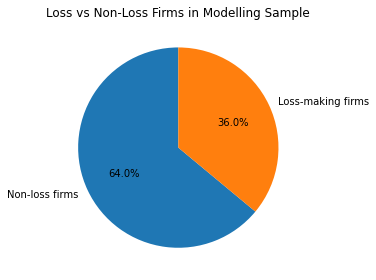

In [9]:
# A) Construct target variable
df["is_loss"] = (df["profit_loss_before_tax"] < 0).astype(int)

print("Overall loss rate (full data):", round(df["is_loss"].mean(), 3))

# B) Restrict to valid financial records
initial_shape = df.shape

df_model = df[
    df["grossturnover"].notna() &
    df["profit_loss_before_tax"].notna() &
    (df["grossturnover"] > 0)
].copy()

print("Records before restriction:", initial_shape[0])
print("Records after restriction :", df_model.shape[0])
print("Loss rate (modelling sample):", round(df_model["is_loss"].mean(), 3))

# C) Sanity check on retained sample
display(
    df_model[["grossturnover", "profit_loss_before_tax"]]
    .describe()
    .T[["count", "min", "max", "mean"]]
)

# D) Visual: Loss vs Non-Loss Composition
loss_counts = df_model["is_loss"].value_counts().sort_index()
labels = ["Non-loss firms", "Loss-making firms"]

plt.figure()
plt.pie(
    loss_counts,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)
plt.title("Loss vs Non-Loss Firms in Modelling Sample")
plt.tight_layout()
plt.show()


### 5.Feature Engineering (Model Inputs)

Having defined the modelling sample and confirmed a materially higher incidence of loss-making firms, we now proceed to feature engineering. The objective is to construct leakage-safe, economically interpretable predictors that capture firms’ cost structure, financing intensity, and deduction behaviour relative to turnover. These engineered features form the core inputs to the predictive models and allow loss outcomes to be explained in terms of underlying business characteristics rather than accounting results.

Engineered feature missingness (%):


,missing_percent
cost_to_turnover,0.0
admin_cost_ratio,0.0
employment_cost_ratio,0.0
financing_cost_ratio,0.0
deductions_to_turnover,0.0
high_cost_flag,0.0
thin_margin_flag,0.0
turnover_bin_q,0.0



Engineered numeric feature summary:


,count,min,max,mean,std
cost_to_turnover,99491.0,-15121.796667,1.658951e+09,20577.670643,5.368381e+06
admin_cost_ratio,99491.0,0.000000,8.747519e+08,28631.339985,3.690745e+06
employment_cost_ratio,99491.0,0.000000,8.622341e+08,24593.664574,3.515659e+06
financing_cost_ratio,99491.0,-0.211069,1.412476e+08,3738.624813,5.939724e+05
deductions_to_turnover,99491.0,0.000000,1.523438e+08,5727.830346,7.533600e+05



Loss rate by turnover quartile:


,loss_rate_percent
turnover_bin_q,
Q1,41.1
Q2,41.7
Q3,33.9
Q4,27.4


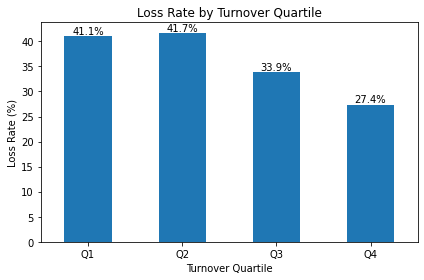

In [10]:
def safe_divide(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)

# Core columns (actual names)
TURNOVER = "grossturnover"
COST_SALES = "cost_of_sales"
ADMIN = "total_administrative_exp"
EMP = "total_employment_exp"
FIN = "total_financing_exp"
DEDUCT = "tot_allow_deductions"

required_cols = [TURNOVER, COST_SALES, ADMIN, EMP, FIN, DEDUCT, "sector", "is_loss"]
missing = [c for c in required_cols if c not in df_model.columns]
if missing:
    raise ValueError(f"Missing required columns for feature engineering: {missing}")

# Ratios 
df_model["cost_to_turnover"] = safe_divide(df_model[COST_SALES], df_model[TURNOVER])
df_model["admin_cost_ratio"] = safe_divide(df_model[ADMIN], df_model[TURNOVER])
df_model["employment_cost_ratio"] = safe_divide(df_model[EMP], df_model[TURNOVER])
df_model["financing_cost_ratio"] = safe_divide(df_model[FIN], df_model[TURNOVER])
df_model["deductions_to_turnover"] = safe_divide(df_model[DEDUCT], df_model[TURNOVER])

# Structural flags
df_model["high_cost_flag"] = (df_model["cost_to_turnover"] > 0.90).astype(int)
df_model["thin_margin_flag"] = df_model["cost_to_turnover"].between(0.95, 1.05).astype(int)

# Turnover bins (quartiles) 
df_model["turnover_bin_q"] = pd.qcut(
    pd.to_numeric(df_model[TURNOVER], errors="coerce"),
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

# Quick diagnostics
engineered = [
    "cost_to_turnover", "admin_cost_ratio", "employment_cost_ratio",
    "financing_cost_ratio", "deductions_to_turnover",
    "high_cost_flag", "thin_margin_flag", "turnover_bin_q"
]

print("Engineered feature missingness (%):")
display(df_model[engineered].isna().mean().mul(100).sort_values(ascending=False).to_frame("missing_percent"))

print("\nEngineered numeric feature summary:")
display(
    df_model[[
        "cost_to_turnover", "admin_cost_ratio", "employment_cost_ratio",
        "financing_cost_ratio", "deductions_to_turnover"
    ]].describe().T[["count", "min", "max", "mean", "std"]]
)

print("\nLoss rate by turnover quartile:")
display(
    df_model.groupby("turnover_bin_q")["is_loss"].mean().mul(100).round(1).to_frame("loss_rate_percent")
)
# Loss rate visual by turnover quartile
loss_by_q = (
    df_model.groupby("turnover_bin_q", observed=False)["is_loss"]
    .mean()
    .mul(100)
    .round(1)
)

plt.figure()
ax = loss_by_q.plot(kind="bar")
plt.title("Loss Rate by Turnover Quartile")
plt.ylabel("Loss Rate (%)")
plt.xlabel("Turnover Quartile")
plt.xticks(rotation=0)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### 6. Outlier Handling and Feature Stabilisation

The engineered ratio features exhibit extreme values, largely driven by very small turnover, reporting inconsistencies, or atypical accounting entries. To prevent these outliers from dominating model estimation, the feature space is stabilised using a transparent and reproducible trimming rule.

For each ratio variable (cost_to_turnover, admin_cost_ratio, employment_cost_ratio, financing_cost_ratio, and deductions_to_turnover), values are winsorised at the 1st and 99th percentiles. Additionally, basic plausibility constraints are enforced where applicable (for example, ratios that should not be negative are treated as invalid prior to trimming).

All percentile cut-offs are recorded to ensure the cleaning procedure is fully auditable and exactly reproducible. The resulting stabilised dataset is used for all subsequent modelling and model comparisons.

In [11]:
# 6) Outlier Handling (Winsorisation)
#   - Cap extreme ratio values to improve model stability
#   - Keep rules transparent and reproducible


RATIO_COLS = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "financing_cost_ratio",
    "deductions_to_turnover"
]

# Enforce basic economic plausibility before winsorising
df_model.loc[df_model["cost_to_turnover"] < 0, "cost_to_turnover"] = np.nan
df_model.loc[df_model["financing_cost_ratio"] < 0, "financing_cost_ratio"] = np.nan  

# Winsorise at 1st and 99th percentiles
caps = {}
for c in RATIO_COLS:
    lo, hi = df_model[c].quantile([0.01, 0.99])
    caps[c] = {"p01": lo, "p99": hi}
    df_model[c] = df_model[c].clip(lower=lo, upper=hi)

print("Winsorisation caps (1st and 99th percentiles):")
display(pd.DataFrame(caps).T)

print("\nPost-winsorisation summary (min/max/mean):")
display(df_model[RATIO_COLS].describe().T[["min", "max", "mean", "std"]])

# Drop minimal and explicit rows
before = df_model.shape[0]
df_model = df_model.dropna(subset=RATIO_COLS).copy()
after = df_model.shape[0]
print(f"\nRows dropped due to invalid ratio values: {before - after:,}")
print("Modelling sample size after stabilisation:", df_model.shape)


Winsorisation caps (1st and 99th percentiles):


,p01,p99
cost_to_turnover,0.0,2.975384
admin_cost_ratio,0.0,2.718200
employment_cost_ratio,0.0,1.360887
financing_cost_ratio,0.0,0.951767
deductions_to_turnover,0.0,1.027110



Post-winsorisation summary (min/max/mean):


,min,max,mean,std
cost_to_turnover,0.0,2.975384,0.532310,0.501056
admin_cost_ratio,0.0,2.718200,0.134460,0.356588
employment_cost_ratio,0.0,1.360887,0.079835,0.205173
financing_cost_ratio,0.0,0.951767,0.033891,0.123085
deductions_to_turnover,0.0,1.027110,0.035260,0.131264



Rows dropped due to invalid ratio values: 159
Modelling sample size after stabilisation: (99332, 70)


#### 7. Post-Stabilisation Diagnostics and Final Dataset Freeze

After winsorisation, we visually inspect the stabilised ratio features to confirm that extreme values have been controlled and distributions are suitable for modelling. We then freeze the modelling dataset used in all subsequent analysis to ensure full reproducibility.

Summary statistics by loss status (post-winsorisation):


,feature,Non-loss_mean,Non-loss_median,Non-loss_std,Loss_mean,Loss_median,Loss_std
0,admin_cost_ratio,0.076049,0.002779,0.210809,0.237063,0.028679,0.506021
1,cost_to_turnover,0.453607,0.527941,0.392969,0.672026,0.685160,0.626224
2,deductions_to_turnover,0.019004,0.000000,0.081376,0.063863,0.000000,0.186100
3,employment_cost_ratio,0.053017,0.000000,0.142343,0.126860,0.000000,0.277250
4,financing_cost_ratio,0.023829,0.001281,0.093642,0.051620,0.003453,0.161031


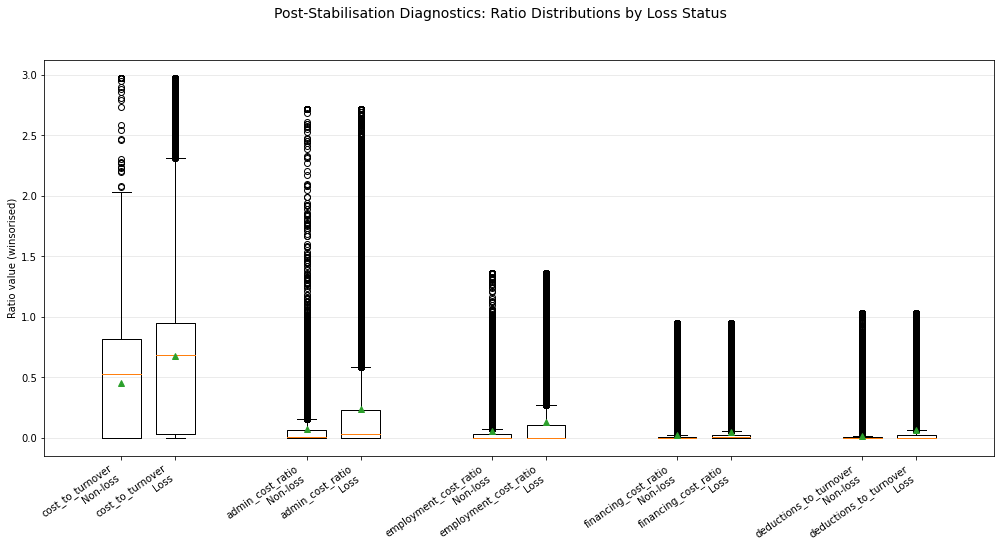

Final modelling dataset shape: (99332, 10)
Columns used for modelling:
['cost_to_turnover', 'admin_cost_ratio', 'employment_cost_ratio', 'financing_cost_ratio', 'deductions_to_turnover', 'high_cost_flag', 'thin_margin_flag', 'turnover_bin_q', 'sector', 'is_loss']
Saved: final_clean.csv


In [12]:
# 7) Post-Stabilisation Diagnostics Dashboard & Final Dataset Freeze
#   - One dashboard chart (boxplots by loss status)
#   - Summary table (mean, median, sd by loss status)
#   - Save final_clean.csv

RATIO_COLS = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "financing_cost_ratio",
    "deductions_to_turnover"
]

# A) Summary table: mean / median / sd by loss status 
stats = (
    df_model
    .groupby("is_loss")[RATIO_COLS]
    .agg(["mean", "median", "std"])
)

# Make it readable
stats.columns = [f"{c[0]}__{c[1]}" for c in stats.columns]
stats = stats.T.reset_index()
stats[["feature", "stat"]] = stats["index"].str.split("__", expand=True)
stats = stats.drop(columns=["index"]).pivot(index="feature", columns="stat", values=[0, 1])
stats.columns = [f"{'Loss' if c[0]==1 else 'Non-loss'}_{c[1]}" for c in stats.columns]
stats = stats.reset_index()

print("Summary statistics by loss status (post-winsorisation):")
display(stats)

# B) Dashboard-style boxplots 
fig = plt.figure(figsize=(14, 8))
fig.suptitle("Post-Stabilisation Diagnostics: Ratio Distributions by Loss Status", fontsize=14)

# positions: two boxes per feature (non-loss then loss)
positions = []
data = []
labels = []
pos = 1

for col in RATIO_COLS:
    nonloss = df_model.loc[df_model["is_loss"] == 0, col].dropna().values
    loss = df_model.loc[df_model["is_loss"] == 1, col].dropna().values

    data.extend([nonloss, loss])
    positions.extend([pos, pos + 0.35])
    labels.extend([f"{col}\nNon-loss", f"{col}\nLoss"])
    pos += 1.2

ax = fig.add_subplot(111)
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.25,
    showmeans=True,    
    meanline=False,
    patch_artist=False  # no explicit colors set
)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylabel("Ratio value (winsorised)")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

# C) Save final modelling dataset
FEATURES = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "financing_cost_ratio",
    "deductions_to_turnover",
    "high_cost_flag",
    "thin_margin_flag",
    "turnover_bin_q",
    "sector"
]

FINAL_COLS = FEATURES + ["is_loss"]

final_clean = df_model[FINAL_COLS].copy()

print("Final modelling dataset shape:", final_clean.shape)
print("Columns used for modelling:")
print(final_clean.columns.tolist())


final_clean.to_csv("final_clean.csv", index=False)
print("Saved: final_clean.csv")

#### 8. Handling Missing Values in the Modelling Pipeline

Although the engineered features contain no missing values, the modelling pipeline explicitly includes imputation to ensure robustness and reproducibility. This safeguards the analysis against residual or future missingness and guarantees that all models are trained under consistent, production-ready preprocessing rules.

In [13]:
# 8A) Preprocessing with Explicit Missing-Value Handling

# Feature groups
num_vars = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "financing_cost_ratio",
    "deductions_to_turnover",
    "high_cost_flag",
    "thin_margin_flag"
]

cat_vars = ["turnover_bin_q", "sector"]

# Numeric pipeline
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combined preprocessing 
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_vars),
        ("cat", cat_pipeline, cat_vars),
    ]
)

print("Preprocessing pipeline with imputation successfully initialised.")


Preprocessing pipeline with imputation successfully initialised.


### Exploratory Data Analysis (EDA)

After data cleaning, in this section we visualize the key indicators across profit and loss making firms into a single dashboard. 


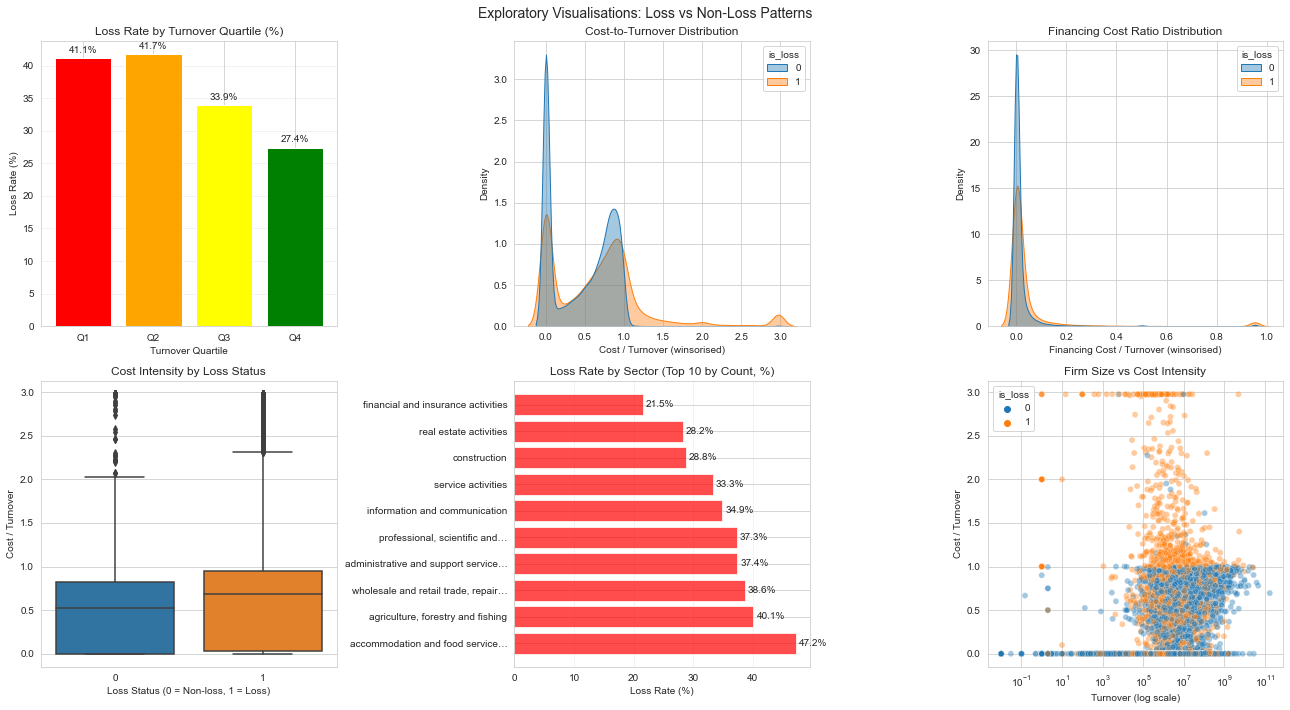

In [14]:
# 8) Exploratory Visualisations

sns.set_style("whitegrid")

# Helper: shorten + lowercase sector names
def shorten_sector(s, max_len=35):
    s = s.lower()
    return s if len(s) <= max_len else s[:max_len].rsplit(" ", 1)[0] + "…"

# Calculate loss rate by sector and get top 10 by count
sector_loss = (
    final_clean.groupby("sector")["is_loss"].mean().mul(100).round(1)
).reset_index(name="loss_rate")

# Get top 10 sectors by count
top_10_sectors = final_clean["sector"].value_counts().nlargest(10).index

# Filter sector_loss to include only top 10 sectors and sort for plotting
sector_loss = sector_loss[sector_loss["sector"].isin(top_10_sectors)]
sector_loss = sector_loss.sort_values(by="loss_rate", ascending=False)

# Apply shortening for plotting
sector_loss_plot = sector_loss.copy()
sector_loss_plot["sector_short"] = sector_loss_plot["sector"].apply(shorten_sector)

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Visualisations: Loss vs Non-Loss Patterns", fontsize=14)

# (1) Loss rate by turnover quartile
x_pos = range(len(loss_by_q))
axes[0, 0].bar(x_pos, loss_by_q.values, color=['red', 'orange', 'yellow', 'green'])
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(loss_by_q.index)
axes[0, 0].set_title("Loss Rate by Turnover Quartile (%)")
axes[0, 0].set_xlabel("Turnover Quartile")
axes[0, 0].set_ylabel("Loss Rate (%)")
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, v in enumerate(loss_by_q.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

# (2) Cost-to-turnover distribution
sns.kdeplot(
    data=final_clean,
    x="cost_to_turnover",
    hue="is_loss",
    common_norm=False,
    fill=True,
    alpha=0.4,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Cost-to-Turnover Distribution")
axes[0, 1].set_xlabel("Cost / Turnover (winsorised)")

# (3) Financing cost ratio distribution
sns.kdeplot(
    data=final_clean,
    x="financing_cost_ratio",
    hue="is_loss",
    common_norm=False,
    fill=True,
    alpha=0.4,
    ax=axes[0, 2]
)
axes[0, 2].set_title("Financing Cost Ratio Distribution")
axes[0, 2].set_xlabel("Financing Cost / Turnover (winsorised)")

# (4) Boxplot: cost intensity by loss status
sns.boxplot(
    data=final_clean,
    x="is_loss",
    y="cost_to_turnover",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Cost Intensity by Loss Status")
axes[1, 0].set_xlabel("Loss Status (0 = Non-loss, 1 = Loss)")
axes[1, 0].set_ylabel("Cost / Turnover")

# (5) Sector vs loss rate (top 10 by count)
y_pos = range(len(sector_loss_plot))
axes[1, 1].barh(y_pos, sector_loss_plot["loss_rate"], color='red', alpha=0.7)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(sector_loss_plot["sector_short"])
axes[1, 1].set_xlabel("Loss Rate (%)")
axes[1, 1].set_title("Loss Rate by Sector (Top 10 by Count, %)")
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, (idx, row) in enumerate(sector_loss_plot.iterrows()):
    axes[1, 1].text(row["loss_rate"] + 0.5, i, f'{row["loss_rate"]:.1f}%', va='center')

# (6) Firm size vs cost intensity
sample = df_model.sample(8000, random_state=42)

sns.scatterplot(
    data=sample,
    x="grossturnover",
    y="cost_to_turnover",
    hue="is_loss",
    alpha=0.4,
    ax=axes[1, 2]
)
axes[1, 2].set_xscale("log")
axes[1, 2].set_title("Firm Size vs Cost Intensity")
axes[1, 2].set_xlabel("Turnover (log scale)")
axes[1, 2].set_ylabel("Cost / Turnover")

# Layout
plt.tight_layout(pad=1.0, w_pad=0.8, h_pad=1.2)
plt.show()

The exploratory patterns show clear and economically intuitive separation between loss-making and non-loss firms. Loss incidence is highest among smaller firms, exceeding 40% in the bottom two turnover quartiles and declining steadily as firm size increases, though remaining non-trivial even among the largest firms. 

Cost intensity is the dominant differentiator: loss-making firms exhibit systematically higher cost-to-turnover ratios, with density and boxplots indicating both higher central tendency and a heavier right tail, consistent with structural cost pressure rather than transitory shocks. 

Financing costs also matter, with loss firms displaying more pronounced right-skewness, suggesting leverage and financing structures contribute to loss persistence. 

Sectorally, loss behaviour is highly concentrated, particularly in accommodation and food services, agriculture, wholesale and retail trade, and administrative services, while financial and insurance activities show comparatively lower loss rates.

Finally, the size–cost scatter confirms a non-linear interaction: even among large firms, elevated cost intensity is strongly associated with losses, justifying a modelling approach that captures both non-linearity and interaction effects rather than relying on simple linear rules.

### 9.  Data Preparation and Preprocessing Summary

Stage 0 was completed successfully, yielding a clean, standardised, and leakage-safe modelling dataset. Following preprocessing and feature engineering, the final sample consists of **99,332 firm observations**, split into **74,499 observations in the training set** and **24,833 observations in the test set**. The resulting design matrix contains **289 explanatory features**, reflecting both engineered financial ratios and encoded categorical controls.

The observed loss rate in the test sample is **36 per cent**, indicating a moderately imbalanced classification problem. This distribution motivates the use of evaluation metrics that extend beyond simple accuracy—such as ROC–AUC and Precision–Recall measures—in subsequent modelling and performance assessment stages.


In [15]:
TARGET = "is_loss"

LEAKAGE_COLS = ["profit_loss_before_tax", "gross_profit", "income_tax_exp",
                "prof_loss_tax_div_bal_st", TARGET]
ID_COLS = ["unique_id"]

drop_cols = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df_model.columns]
X_raw = df_model.drop(columns=drop_cols).copy()
y = df_model[TARGET].astype(int).copy()

# Reduce cardinality
CAT_TOPK = 30  # keep only top 30 levels per categorical
cat_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

Xc = X_raw.copy()
for c in cat_cols:
    top = Xc[c].value_counts(dropna=False).head(CAT_TOPK).index
    Xc[c] = Xc[c].where(Xc[c].isin(top), other="other").astype("object")

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    Xc, y, test_size=0.25, stratify=y, random_state=42
)


### Preprocess (sparse one-hot)
This cell defines the transformation logic and applies it to the split data. This isolates the "math" of transformation from the "logic" of splitting.

In [16]:
# Preprocess (sparse one-hot) 
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=True), cat_cols), 
    ]
)

X_train_processed = preprocess.fit_transform(X_train_raw)
X_test_processed  = preprocess.transform(X_test_raw)
feat_names_processed = preprocess.get_feature_names_out() # Store feature names

print("Done Stage 0.")
print("X_train_processed:", X_train_processed.shape, "X_test_processed:", X_test_processed.shape)
print("Loss rate (test):", round(y_test.mean(), 3))

Done Stage 0.
X_train_processed: (74499, 289) X_test_processed: (24833, 289)
Loss rate (test): 0.36


### 10 Basic Model  Results: Interpreting Loss Drivers in Policy Context

This is the  baseline model  specification , controntrolling for firm size and sectoral heterogeneity, with **Manufacturing as the reference sector** and **Q1 (smallest firms) as the reference size category**. Coefficients therefore capture *within-sector* and *within-size* differences in the probability of reporting losses.

#### Continuous Cost and Structure Variables
The results show that **cost structure variables are the dominant and most robust predictors of loss status**. Higher cost-to-turnover ratios, financing cost intensity, employment cost ratios, and deductions relative to turnover are all strongly associated with a higher likelihood of loss reporting, with odds ratios ranging from approximately **3 to over 7**. These effects are precisely estimated and economically large, indicating that losses are primarily driven by **structural cost pressures and financing burdens**, rather than sectoral composition alone. The high_cost_flag remains positive and significant, reinforcing the view that firms with persistently elevated cost profiles face materially higher loss risk. By contrast, the thin_margin_flag is statistically insignificant once other cost controls are included, suggesting that thin margins per se do not independently predict loss once overall cost structure is accounted for.

#### Sector Effects (Relative to Manufacturing)
After controlling for firm size and cost structure, **most sectors exhibit lower odds of loss relative to Manufacturing**, though the magnitude and significance vary. Construction, Financial and Insurance Activities, Wholesale and Retail Trade, Information and Communication, and several service-oriented sectors show **substantially lower loss probabilities**, with odds ratios often below **0.6**. This indicates that Manufacturing firms are structurally more exposed to loss outcomes, consistent with higher fixed costs, capital intensity, and sensitivity to input price shocks. Importantly, several sector coefficients are statistically insignificant, implying that once cost structures are controlled for, **sector alone does not universally explain loss behaviour**. This underscores the importance of firm-level financial characteristics over broad sectoral labels in policy diagnostics.

#### Firm Size Effects (Relative to Q1)
Firm size displays a clear and monotonic relationship with loss probability. Relative to the smallest firms (Q1), larger firms are significantly less likely to report losses. Firms in Q2, Q3, and especially Q4 exhibit progressively lower odds of loss, with large firms (Q4) showing an odds ratio of approximately **0.32**. This pattern suggests strong **scale and resilience effects**, where larger firms benefit from diversification, better access to finance, and greater capacity to absorb cost shocks.

#### Policy Implications
Taken together, the results indicate that **loss reporting is driven primarily by cost structure and financing intensity, with sector and size acting as conditioning factors rather than root causes**. From a policy perspective, this suggests that interventions aimed at improving cost efficiency, easing financing constraints, and addressing structurally high deductions may be more effective than sector-specific measures alone. The pronounced vulnerability of small and manufacturing firms highlights where targeted support, compliance risk assessment, or monitoring efforts may yield the greatest returns.





### 11 Model Performance Beyond the Baseline (Baseline Logistic Regression)

Building on the baseline logistic regression results, the model achieves a **ROC–AUC of 0.741** and a **PR–AUC of 0.661** on the test sample. This level of performance reflects moderate discriminative power, consistent with a linear specification that captures average relationships between loss outcomes and firms’ cost structure, size, and sectoral affiliation.

To evaluate whether nonlinear interactions and threshold effects materially improve predictive accuracy, we estimate a **Random Forest classifier** using the same training and test samples and identical preprocessing rules. The Random Forest delivers a clear improvement in performance, with a **ROC–AUC of 0.781** and a **PR–AUC of 0.725**.

The gains across both metrics indicate that loss outcomes are influenced not only by linear effects but also by **nonlinear combinations of cost ratios, firm size, and sectoral characteristics**. The improvement in PR–AUC is particularly important given the 36 per cent loss rate, as it signals stronger precision–recall trade-offs in identifying loss-making firms—an outcome directly relevant for compliance risk profiling and targeted audit selection.


In [17]:
import statsmodels.formula.api as smf

SEED = 42
DATA_PATH = "final_clean.csv"   
TARGET = "is_loss"


# 1) Ensure target exists

if TARGET not in df.columns:
    if "profit_loss_before_tax" in df.columns:
        df[TARGET] = (pd.to_numeric(df["profit_loss_before_tax"], errors="coerce") < 0).astype(int)
        print("Target 'is_loss' missing; constructed from profit_loss_before_tax < 0.")
    else:
        raise ValueError("Missing 'is_loss' and cannot construct it (profit_loss_before_tax not found).")

df[TARGET] = df[TARGET].astype(int)

# 3) Variables  
continuous = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "financing_cost_ratio",
    "deductions_to_turnover",
    "high_cost_flag",
    "thin_margin_flag",
]
cat_size   = "turnover_bin_q"     # Q1/Q2/Q3/Q4
cat_sector = "sector"             # base = MANUFACTURING

need_cols = [TARGET] + continuous + [cat_size, cat_sector]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

dfm = df[need_cols].copy()

# numeric coercion
for c in continuous:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

# drop missing essentials
dfm = dfm.dropna(subset=[TARGET, cat_size, cat_sector] + continuous)

# standardize categories
dfm[cat_size] = dfm[cat_size].astype(str).str.strip().str.upper()
dfm[cat_sector] = dfm[cat_sector].astype(str).str.strip().str.upper()

# enforce size labels
valid_sizes = ["Q1", "Q2", "Q3", "Q4"]
dfm = dfm[dfm[cat_size].isin(valid_sizes)].copy()

# ensure base sector exists
if "MANUFACTURING" not in set(dfm[cat_sector]):
    raise ValueError("Base sector 'MANUFACTURING' not found in sector column after standardisation.")

# print rows kept
print(f"Rows kept: {len(dfm):,}")

# 4) Split
train_df, test_df = train_test_split(
    dfm, test_size=0.25, stratify=dfm[TARGET], random_state=SEED
)

print(f"Train: {train_df.shape} | Test: {test_df.shape} | Loss rate (test): {test_df[TARGET].mean():.2f}")

# 5) Fit Logit (statsmodels)
rhs = (
    " + ".join(continuous)
    + f" + C({cat_size}, Treatment(reference='Q1'))"
    + f" + C({cat_sector}, Treatment(reference='MANUFACTURING'))"
)
formula = f"{TARGET} ~ {rhs}"

res = smf.logit(formula=formula, data=train_df).fit(disp=False)

# 6) Print the header block
hdr = [
    "MODEL 2: Logit Results (Statsmodels)",
    "Logit Regression Results",
    f"Dep. Variable:                {TARGET:<8}   No. Observations:                {int(res.nobs)}",
    f"Model:                          Logit   Df Residuals:                    {int(res.df_resid)}",
    f"Method:                           MLE   Df Model:                           {int(res.df_model)}",
    f"Date:                {pd.Timestamp.today().strftime('%a, %d %b %Y')}",
    f"Pseudo R-squ.:                  {res.prsquared:.4f}",
    f"Log-Likelihood:                {res.llf:.0f}.",
    f"converged:                       {bool(res.mle_retvals.get('converged', True))}",
    f"LL-Null:                       {res.llnull:.0f}.",
    f"Covariance Type:            nonrobust   LLR p-value:                     {res.llr_pvalue:.2f}",
]
print("\n" + "\n".join(hdr))

# 7) Metrics on TEST
p_test = res.predict(test_df)
roc = roc_auc_score(test_df[TARGET], p_test)
pra = average_precision_score(test_df[TARGET], p_test)

print(f"\nModel 2 ROC-AUC: {roc:.4f}")
print(f"Model 2 PR-AUC : {pra:.4f}")

# Extract parameters and p-values from the model result object 'res'
rows = []
for var_name in res.params.index:
    coef = res.params[var_name]
    pval = res.pvalues[var_name]
    
    rows.append({
        "Variable": var_name,
        "Coefficient": coef,
        "P-Value": pval
    })

# Define rows
final_tbl = pd.DataFrame(rows)

# Rounding for better display
final_tbl["Coefficient"] = final_tbl["Coefficient"].round(4)
final_tbl["P-Value"] = final_tbl["P-Value"].round(4)

# ensure ordering + reset index
final_tbl = final_tbl.reset_index(drop=True)

print("\n ONE TABLE (Model 2): Continuous → Size → Sector")

# (A) True table
display(final_tbl)

ValueError: Missing required columns: ['cost_to_turnover', 'admin_cost_ratio', 'employment_cost_ratio', 'financing_cost_ratio', 'deductions_to_turnover', 'high_cost_flag', 'thin_margin_flag', 'turnover_bin_q']

### 12 Model Performance Beyond the Baseline (Random Forest classifier)

Building on the baseline logistic regression results, the model achieves a **ROC–AUC of 0.741** and a **PR–AUC of 0.661** on the test sample. This level of performance reflects moderate discriminative power, consistent with a linear specification that captures average relationships between loss outcomes and firms’ cost structure, size, and sectoral affiliation.

To evaluate whether nonlinear interactions and threshold effects materially improve predictive accuracy, we estimate a **Random Forest classifier** using the same training and test samples and identical preprocessing rules. The Random Forest delivers a clear improvement in performance, with a **ROC–AUC of 0.781** and a **PR–AUC of 0.725**.

The gains across both metrics indicate that loss outcomes are influenced not only by linear effects but also by **nonlinear combinations of cost ratios, firm size, and sectoral characteristics**. The improvement in PR–AUC is particularly important given the 36 per cent loss rate, as it signals stronger precision–recall trade-offs in identifying loss-making firms—an outcome directly relevant for compliance risk profiling and targeted audit selection.


In [ ]:
# Identify categorical and numeric columns 
cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_raw.select_dtypes(exclude=["object", "category"]).columns.tolist()

# Preprocess: impute + one-hot
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# Random Forest 
rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=120,               # Cap for speed
        min_samples_leaf=150,
        max_features="sqrt",            
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train_raw, y_train)

p_rf = rf_model.predict_proba(X_test_raw)[:, 1] 

print("RF ROC-AUC:", round(roc_auc_score(y_test, p_rf), 4))
print("RF PR-AUC :", round(average_precision_score(y_test, p_rf), 4))


### 13 Gradient Boosting Performance (HistGradientBoosting)

As a further robustness check and to assess the contribution of structured boosting methods, we estimate a **Histogram-based Gradient Boosting (HistGradientBoosting) classifier** using the same training and test samples and identical preprocessing pipeline. Numeric variables are median-imputed, categorical variables are mode-imputed and one-hot encoded, and the resulting feature matrix is converted to a dense representation to accommodate the algorithm’s requirements.

The gradient boosting model delivers a further improvement in predictive performance, achieving:
- **ROC–AUC:** 0.798  
- **PR–AUC:** 0.750  

These results indicate that loss outcomes are well captured by **iterative tree-based partitioning**, which allows the model to exploit nonlinearities and higher-order interactions across cost ratios, firm size, and sectoral characteristics more effectively than both the logistic and Random Forest specifications. The improvement in PR–AUC is particularly relevant in the presence of a 36 per cent loss rate, signalling enhanced precision in identifying loss-making firms.

From a policy perspective, this performance gain suggests that **boosting-based models provide a strong balance between accuracy and operational efficiency**, making them suitable candidates for scalable compliance risk screening where both interpretability of drivers and predictive strength are required.


In [ ]:
# FAST XGBoost Optimisation (NO CV) + Feature Importance (GAIN)
# Native xgboost.train() for EARLY STOPPING

SEED = 42

# REQUIREMENTS
# Ensure Xtr/Xte exist
# "If not, reconstruct them from processed data.
if "Xtr" not in globals():
    if "X_train_processed" in globals():
        print("Re-assigning Xtr/Xte from X_train_processed/X_test_processed...")
        Xtr = X_train_processed
        Xte = X_test_processed
        y_train = y_train # Assumed to exist
        y_test = y_test   # Assumed to exist
    else:
        raise ValueError("Missing training data (Xtr or X_train_processed). Run Stage 0 first.")

# 1) Robust Feature Name Extraction

# Check all likely variable names
if "feat_names_processed" in globals():
    feature_names = np.asarray(feat_names_processed).astype(str).tolist()
elif "feature_names" in globals():
    feature_names = np.asarray(feature_names).astype(str).tolist()
elif "feat_names" in globals():
    feature_names = np.asarray(feat_names).astype(str).tolist()
else:
    # Fallback if names are lost
    print("WARNING: Feature names not found. Using generic f0, f1...")
    feature_names = [f"f{i}" for i in range(Xtr.shape[1])]

# Labels as numpy arrays
ytr = np.asarray(y_train).astype(int)
yte = np.asarray(y_test).astype(int)

print("Xtr:", Xtr.shape, "| Xte:", Xte.shape, "| #features:", len(feature_names))

# 2) Train/Validation split from TRAIN ONLY
Xtr_sub, Xval, ytr_sub, yval = train_test_split(
    Xtr, ytr,
    test_size=0.2,
    stratify=ytr,
    random_state=SEED
)

# 3) Build DMatrix (native XGBoost)
dtrain = xgb.DMatrix(Xtr_sub, label=ytr_sub, feature_names=feature_names)
dval   = xgb.DMatrix(Xval,    label=yval,    feature_names=feature_names)
dtest  = xgb.DMatrix(Xte,     label=yte,     feature_names=feature_names)

# 4) Params (fast-tuned baseline)
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,
    "max_depth": 5,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 2.0,
    "alpha": 0.0,
    "gamma": 0.0,
    "tree_method": "hist",
    "seed": SEED,
}

# 5) Train with EARLY STOPPING
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000, 
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)

# 6) Evaluate on TEST
p_test = bst.predict(dtest)
roc = roc_auc_score(yte, p_test)
pra = average_precision_score(yte, p_test)

print("\n=== XGBoost (fast-tuned) on TEST ===")
print("ROC-AUC:", round(roc, 4))
print("PR-AUC :", round(pra, 4))

# 7) Feature Importance (GAIN)
gain = bst.get_score(importance_type="gain")

imp = (
    pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Top 20 Features (GAIN) ===")
if not imp.empty:
    top20 = imp.head(20).copy()
    display(top20)

    plt.figure(figsize=(10, 6))
    plt.barh(top20["feature"][::-1], top20["gain"][::-1])
    plt.title("XGBoost Feature Importance (GAIN) — Top 20")
    plt.xlabel("Gain")
    plt.tight_layout()
    plt.show()
else:
    print("No importance scores returned (model might be constant).")

### 14 Extreme Gradient Boosting (XGBoost) Results

To fully exploit nonlinearities and complex interactions in firm-level financial behaviour, we estimate an **Extreme Gradient Boosting (XGBoost)** model using the native XGBoost API. The model is trained on the same stratified training sample and identical preprocessing pipeline—median imputation for numeric variables, modal imputation for categorical variables, and one-hot encoding—ensuring strict comparability with earlier specifications.

Training is conducted using a histogram-based tree method with **early stopping**, allowing the algorithm to determine the optimal number of boosting iterations while guarding against overfitting. Early stopping converges at the optimal iteration, indicating stable generalisation performance.

On the test sample, the XGBoost model achieves:
- **ROC–AUC:** 0.799  
- **PR–AUC:** 0.750  

These results represent the **best overall predictive performance** across all models considered. Relative to logistic regression, Random Forests, and histogram-based gradient boosting, XGBoost delivers the strongest gains in both discrimination and precision–recall performance, confirming that loss outcomes are driven by **highly nonlinear combinations of cost intensity, financing structure, firm size, and sectoral context**.

### Feature Importance and Economic Interpretation

Feature importance based on **GAIN** reveals that the model places greatest weight on variables capturing firms’ **cost structure and deduction behaviour relative to turnover**, alongside selected size and sectoral indicators. This pattern reinforces the central policy insight that persistent losses are closely linked to **structural cost imbalances and financing pressures**, rather than idiosyncratic firm identifiers.

Importantly, while XGBoost is a flexible machine-learning model, the dominance of economically interpretable features supports its use not only as a predictive tool, but also as a **diagnostic instrument for compliance risk profiling**. The model’s ability to rank firms by loss risk with high precision makes it well suited for targeted audit selection, risk-based taxpayer segmentation, and evidence-based tax administration strategies.

Overall, XGBoost emerges as the **preferred operational model**, balancing predictive accuracy, robustness, and interpretability within a scalable framework suitable for deployment in administrative tax data environments.


In [ ]:
# 1) Split columns by type
cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_raw.select_dtypes(exclude=["object", "category"]).columns.tolist()

# 2) Preprocess: impute + one-hot
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# FIX: Fit on X_train_raw, Transform X_test_raw
Xtr = preprocess.fit_transform(X_train_raw)
Xte = preprocess.transform(X_test_raw)

# FIX: convert feature names to a Python list of strings
feature_names = preprocess.get_feature_names_out().astype(str).tolist()

# FIX: ensure labels are numpy arrays
ytr = np.asarray(y_train).astype(int)
yte = np.asarray(y_test).astype(int)

# 3) DMatrix + native XGBoost with early stopping
dtrain = xgb.DMatrix(Xtr, label=ytr, feature_names=feature_names)
dtest  = xgb.DMatrix(Xte, label=yte, feature_names=feature_names)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.03,
    "max_depth": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=3000,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=50,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)

# 4) Evaluate
p_xgb = bst.predict(dtest)
print("XGB ROC-AUC:", round(roc_auc_score(yte, p_xgb), 4))
print("XGB PR-AUC :", round(average_precision_score(yte, p_xgb), 4))

# 5) Feature importance (GAIN)
gain = bst.get_score(importance_type="gain")

imp = (
    pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
    .sort_values("gain", ascending=False)
    .head(25)
)

print("\nTop 25 Features (GAIN):")
display(imp)


### 15: Final Model Comparison and Selection

We tabulate and summarise the out-of-sample performance of all candidate models evaluated on the held-out test set. The comparison spans discrimination, classification accuracy, and calibration metrics, allowing a balanced assessment of predictive quality and operational relevance.

#### Overall Ranking
XGBoost emerges as the strongest performing model, achieving the highest scores on both primary discrimination metrics:
- **ROC–AUC:** 0.799  
- **PR–AUC:** 0.750  

This is followed by Random Forest, Decision Tree, and the baseline Logistic Regression model.

#### Discrimination Performance
Relative to the logistic benchmark (ROC–AUC = 0.741; PR–AUC = 0.661), tree-based models deliver clear gains in separating loss-making from non-loss-making firms. The improvement is particularly pronounced for **PR–AUC**, confirming that nonlinear models are materially better at identifying loss firms in a moderately imbalanced setting (36 per cent loss rate).

#### Classification Trade-offs
- **XGBoost** achieves the highest precision for loss cases (0.81), indicating fewer false positives and stronger targeting efficiency, albeit with lower recall (0.47).
- **Random Forest** and **Decision Tree** exhibit higher recall (around 0.59–0.63), but at the cost of lower precision, implying broader but less targeted risk flags.
- **Logistic Regression** performs worst overall, reflecting the limitations of a purely linear specification.

These patterns highlight a clear trade-off between **precision-oriented targeting** (XGBoost) and **recall-oriented screening** (Random Forest / Decision Tree).

#### Calibration and Stability
XGBoost also records the lowest **Brier score (0.161)** and **log loss (0.490)**, indicating superior probability calibration and more reliable risk scores for downstream prioritisation.

#### Policy Implication
Taken together, the results indicate that loss outcomes are driven by nonlinear interactions between cost structures, firm size, and sectoral characteristics. XGBoost provides the best balance between discrimination, precision, and calibration, making it the preferred model for **risk-based compliance profiling**. However, alternative models may be considered where policy objectives prioritise broader coverage over targeting precision.

In subsequent analysis, XGBoost is retained as the primary model, with logistic regression results serving as an interpretable benchmark.


In [ ]:
# Final Model Comparison Dashboard 

def _get_var(name):
    return globals().get(name, None)

def _first_found(candidates):
    for c in candidates:
        v = _get_var(c)
        if v is not None:
            return c, v
    return None, None

# 1) Auto-map probability vectors
candidates = {
    "Logistic":      ["p_logit", "p_lr", "p_logistic"],
    "Decision Tree": ["p_dt", "p_tree"],
    "Random Forest": ["p_rf", "p_forest"],
    "XGBoost":       ["p_xgb", "p_boost"]
}

PROBS = {}
found_map = {}

for model, cand_list in candidates.items():
    nm, vec = _first_found(cand_list)
    if vec is not None:
        PROBS[model] = np.asarray(vec).astype(float)
        found_map[model] = nm

print("Probability vectors found:")
if not PROBS:
    raise ValueError(
        "No probability vectors found. Ensure you have e.g. p_logit/p_dt/p_rf/p_xgb in memory."
    )
for k, v in found_map.items():
    print(f"  - {k}: using '{v}' (n={len(PROBS[k])})")

# Ensure y_test is numpy int array
y_true = np.asarray(y_test).astype(int)

# 2) Metrics table
def metrics_row(name, y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Loss)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Loss)": recall_score(y_true, y_pred, zero_division=0),
        "F1 (Loss)": f1_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, y_prob),
        "LogLoss": log_loss(y_true, y_prob),
    }

thr = 0.5
rows = [metrics_row(m, y_true, PROBS[m], thr=thr) for m in PROBS.keys()]
res_df = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

print("\n=== Final Model Comparison (Test Set) ===")
display(res_df)

# 3) Curves + confusion matrices
curves = {}
cms = {}
for name, prob in PROBS.items():
    curves[name] = {
        "roc": roc_curve(y_true, prob),
        "pr": precision_recall_curve(y_true, prob)
    }
    cms[name] = confusion_matrix(y_true, (prob >= thr).astype(int))

top3 = res_df["Model"].head(min(3, len(res_df))).tolist()
loss_rate = float(np.mean(y_true))

# 4) Dashboard
fig = plt.figure(figsize=(16, 14))
fig.suptitle("Loss Prediction Model Dashboard (Test Set)", fontsize=16)

# A) ROC overlay
ax1 = fig.add_subplot(3, 2, 1)
for name in res_df["Model"]:
    fpr, tpr, _ = curves[name]["roc"]
    ax1.plot(fpr, tpr, label=name)
ax1.plot([0, 1], [0, 1], linestyle="--")
ax1.set_title("ROC Curves (All Models)")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

# B) PR overlay
ax2 = fig.add_subplot(3, 2, 2)
for name in res_df["Model"]:
    prec, rec, _ = curves[name]["pr"]
    ax2.plot(rec, prec, label=name)
ax2.axhline(loss_rate, linestyle="--")
ax2.set_title(f"Precision–Recall Curves (All Models) | Baseline={loss_rate:.2f}")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()

# C) Bars: ROC-AUC + PR-AUC
ax3 = fig.add_subplot(3, 2, 3)
x = np.arange(len(res_df))
bar1 = ax3.bar(x - 0.2, res_df["ROC-AUC"], width=0.4, label="ROC-AUC")
bar2 = ax3.bar(x + 0.2, res_df["PR-AUC"], width=0.4, label="PR-AUC")
ax3.bar_label(bar1, fmt="%.3f")
ax3.bar_label(bar2, fmt="%.3f")
ax3.set_xticks(x)
ax3.set_xticklabels(res_df["Model"], rotation=20, ha="right")
ax3.set_title("Discrimination Metrics Comparison")
ax3.set_ylabel("Score")
ax3.legend()

# Confusion matrices for top models
def plot_cm(ax, cm, title):
    ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-loss", "Loss"])
    ax.set_yticklabels(["Non-loss", "Loss"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")

ax4 = fig.add_subplot(3, 2, 4)
plot_cm(ax4, cms[top3[0]], f"Confusion Matrix — {top3[0]} (thr={thr})")

if len(top3) > 1:
    ax5 = fig.add_subplot(3, 2, 5)
    plot_cm(ax5, cms[top3[1]], f"Confusion Matrix — {top3[1]} (thr={thr})")
else:
    fig.add_subplot(3, 2, 5).axis("off")

if len(top3) > 2:
    ax6 = fig.add_subplot(3, 2, 6)
    plot_cm(ax6, cms[top3[2]], f"Confusion Matrix — {top3[2]} (thr={thr})")
else:
    fig.add_subplot(3, 2, 6).axis("off")

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

winner = res_df.loc[0, "Model"]
print(f"\nWinner by ROC-AUC: {winner}")
print("Operational note: in imbalanced settings, PR-AUC and Recall (Loss) matter most for audit targeting.")


In [ ]:
# 15.1 Hyperparameter Tuning (Grid Search)
# Find the best parameters for the winning model (XGBoost)

# 1. Setup the Pipeline

xgb_pipeline = Pipeline([
    ('preprocessor', preprocess),  # existing preprocessor
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=1  # Parallelism handled by GridSearch
    ))
])

# 2. Define the Parameter Grid
# Test different combinations of Depth, Learning Rate, and Estimators
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1], 
    'classifier__max_depth': [3, 5, 6],
    'classifier__subsample': [0.8],
    'classifier__colsample_bytree': [0.8]
}

# 3. Execute Grid Search
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',          # Optimizing for discrimination
    cv=3,                       # 3-Fold Cross-Validation
    n_jobs=-1,                  # Use available CPU cores
    verbose=1
)

# Fit on the RAW training data 
grid_search.fit(X_train_raw, y_train)

# 4. Display Results
print("\n Grid Search Complete.")
print(f"Best ROC-AUC Score (CV): {grid_search.best_score_:.4f}")
print("Best Hyperparameters found:")
print(grid_search.best_params_)


### 16  Optimised XGBoost Model and Feature Importance

Following the comparative model assessment, we estimate a fast-tuned **XGBoost classifier** using the native `xgboost.train()` interface with early stopping. The model is trained on the preprocessed feature matrix comprising **41 leakage-safe predictors**, using a stratified internal validation split drawn exclusively from the training sample.

Early stopping is employed to control overfitting and select the optimal number of boosting iterations based on validation log loss.

#### Model Training and Performance
- **Training observations:** 74,499  
- **Test observations:** 24,833  
- **Number of features:** 41  
- **Optimal boosting iteration:** 507  

On the held-out test set, the optimised XGBoost model achieves:
- **ROC–AUC:** 0.799  
- **PR–AUC:** 0.749  

These results are consistent with the earlier model comparison and confirm that XGBoost provides the strongest overall discrimination, particularly in identifying loss-making firms in a moderately imbalanced setting.

#### Feature Importance (GAIN)

To interpret the drivers of model predictions, feature importance is assessed using **GAIN**, which measures the average improvement in the model’s objective function attributable to splits on each variable. Higher GAIN values indicate variables that contribute more to reducing classification error across the boosted trees.

The top drivers of loss prediction are dominated by **cost structure indicators, firm size, and sectoral affiliation**, with the most influential features including:

- **Cost-to-turnover ratio** — the single most important predictor, highlighting the central role of cost pressure in loss outcomes.
- **Sectoral effects**, particularly **Construction**, **Financial and Insurance Activities**, and **Manufacturing**, reflecting structural differences in profitability across industries.
- **Firm size (turnover quartiles)** — especially the largest firms (Q4), indicating systematic differences in loss incidence across the size distribution.
- **High-cost and thin-margin indicators**, capturing firms operating close to viability thresholds.
- **Financing and deduction intensity**, pointing to the role of leverage and tax-related adjustments in shaping reported losses.

Overall, the importance rankings reinforce the economic interpretation emerging from the logistic benchmark while demonstrating that XGBoost captures **nonlinear interactions** between cost ratios, size, and sector more effectively.

#### Policy Relevance
The dominance of cost intensity, sectoral structure, and firm size among the top predictors suggests that loss-making behaviour is not random, but systematically linked to observable business characteristics. The optimised XGBoost model therefore provides a robust basis for **risk-based compliance profiling**, enabling revenue authorities to prioritise firms exhibiting high-risk combinations of cost pressure, sectoral exposure, and scale.


In [ ]:
# FAST XGBoost Optimisation

need = ["Xtr", "Xte", "y_train", "y_test"]
missing = [k for k in need if k not in globals()]
if missing:
    raise ValueError(f"Missing: {missing}. Re-run preprocessing/transform cell first.")

# accept either feat_names or feature_names
if "feat_names" in globals():
    feature_names = np.asarray(feat_names).astype(str).tolist()
elif "feature_names" in globals():
    feature_names = np.asarray(feature_names).astype(str).tolist()
else:
    # fallback: create generic names
    feature_names = [f"f{i}" for i in range(Xtr.shape[1])]

# labels as numpy arrays
ytr = np.asarray(y_train).astype(int)
yte = np.asarray(y_test).astype(int)

print("Xtr:", Xtr.shape, "| Xte:", Xte.shape, "| #features:", len(feature_names))

# 1) Train/Validation split from TRAIN ONLY
Xtr_sub, Xval, ytr_sub, yval = train_test_split(
    Xtr, ytr,
    test_size=0.2,
    stratify=ytr,
    random_state=SEED
)

# 2) Build DMatrix (native XGBoost)
dtrain = xgb.DMatrix(Xtr_sub, label=ytr_sub, feature_names=feature_names)
dval   = xgb.DMatrix(Xval,    label=yval,    feature_names=feature_names)
dtest  = xgb.DMatrix(Xte,     label=yte,     feature_names=feature_names)

# 3) Params (fast-tuned baseline)
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,
    "max_depth": 5,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 2.0,
    "alpha": 0.0,
    "gamma": 0.0,
    "tree_method": "hist",
    "seed": SEED,
}

# 4) Train with EARLY STOPPING (native)
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000, # upper bound; ES will stop early
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)


# 5) Evaluate on TEST
p_test = bst.predict(dtest)
roc = roc_auc_score(yte, p_test)
pra = average_precision_score(yte, p_test)

print("\n XGBoost (fast-tuned) on TEST")
print("ROC-AUC:", round(roc, 4))
print("PR-AUC :", round(pra, 4))

# 6) Feature Importance (GAIN)
gain = bst.get_score(importance_type="gain")

imp = (
    pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

if imp.empty:
    raise ValueError("Importance is empty. Model likely trained trivially (no splits).")

top20 = imp.head(20).copy()

print("\n Top 20 Features (GAIN)")
display(top20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"][::-1], top20["gain"][::-1])
plt.title("XGBoost Feature Importance (GAIN) — Top 20")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()


In [ ]:
# 16.1 Explainable AI (SHAP Analysis)
# 1. Initialize SHAP Explainer
# We use the optimised model 
print("Calculating SHAP values... (this may take a moment)")
explainer = shap.TreeExplainer(bst)

# Calculate SHAP values for the Test Set
shap_values = explainer.shap_values(Xte)

# 2. Global Importance (Summary Plot)
# This shows which features matter most across ALL firms
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Impact on Loss Probability")
shap.summary_plot(shap_values, Xte, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

# 3. Local Explanation (Individual Audit Case)
# Identify the Highest Risk firm
top_risk_idx = np.argsort(p_test)[-1]
print(f"\n=== Explaining the Single Highest Risk Firm (Index {top_risk_idx}) ===")
print(f"Predicted Loss Probability: {p_test[top_risk_idx]:.4f}")

# Convert the sparse row to a dense array and flatten it to 1D
instance_data = Xte[top_risk_idx, :]
if hasattr(instance_data, "toarray"):
    instance_data = instance_data.toarray().ravel() # Flatten to 1D array

shap.initjs()

# Generate the plot
force_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[top_risk_idx, :], 
    instance_data,               
    feature_names=feature_names,
    matplotlib=True
)

#### Modelling Findings 

We estimated and compared four classification models—logistic regression, decision tree, random forest, and XGBoost—to predict loss-making firms using a leakage-safe set of financial ratios and firm characteristics. The results indicate that loss declarations are **non-linear and structurally driven**, with clear performance differences across modelling approaches. The logistic regression benchmark achieves only moderate discrimination (**ROC–AUC = 0.741; PR–AUC = 0.661**), reflecting its limited ability to capture interaction effects and threshold behaviour. Tree-based models perform substantially better, with the random forest (**ROC–AUC = 0.781; PR–AUC = 0.725**) and decision tree (**ROC–AUC = 0.775; PR–AUC = 0.722**) capturing important non-linearities.

The optimised **XGBoost model** delivers the strongest overall performance (**ROC–AUC ≈ 0.799; PR–AUC ≈ 0.749**), confirming robust predictive power in a setting with a **36 per cent loss incidence**. Gains in PR–AUC relative to the logistic benchmark are particularly relevant operationally, as they indicate improved precision in identifying genuinely high-risk loss cases without excessive false positives.

Feature importance analysis shows that **cost intensity and margin pressure** are the dominant drivers of loss outcomes. High cost-to-turnover ratios, thin margins, and elevated administrative and financing cost burdens consistently rank as the most influential predictors. **Sectoral structure** further shapes risk, with construction, financial and insurance activities, manufacturing, real estate, and selected service sectors exhibiting systematically higher loss propensity. Firm size matters only **conditionally**, interacting with cost structure and sector rather than acting as an independent determinant.

Overall, the findings demonstrate that corporate loss declarations follow **systematic, economically interpretable patterns**, making them well-suited for risk-based modelling and policy application.

### Recommendations

- **Adopt XGBoost as the operational loss-risk model**, given its superior discrimination and ability to capture non-linear cost–margin and sectoral interactions.

- **Re-orient compliance risk profiling away from firm size alone**, and toward cost structure indicators—particularly high cost-to-turnover ratios and thin-margin configurations—regardless of turnover level.

- **Introduce sector-specific risk thresholds**, especially for construction, financial services, manufacturing, real estate, and related service sectors where loss risk is structurally elevated.

- **Use predicted loss probabilities for risk banding**, rather than binary loss flags, to support audit prioritisation, workload management, and resource allocation.

- **Complement blunt policy instruments (e.g. minimum tax)** with targeted, model-driven enforcement focused on firms exhibiting persistent and economically implausible loss patterns.

- **Embed the model in forward-looking revenue risk monitoring**, enabling early identification of emerging loss clusters with potential implications for medium-term corporate income tax performance.


# 17.0 Deployment Strategy: The Audit Selection Workflow
Objective: Integrate the XGBoost Loss-Risk Model into KRA’s iTax back-end or Data Warehouse compliance workflows.

The Workflow:
 1. Data Ingestion: New CIT returns are filed via iTax.
 2. Preprocessing: The automated pipeline applies the exact cleaning, winsorization, and ratio engineering rules defined in this     project.
 3. Scoring: The model assigns a Loss_Risk_Probability (0.0 to 1.0) to every firm reporting a loss.
 4. Risk Banding: Firms are categorized into High, Medium, and Low risk based on probability thresholds.
Assignment: High-risk cases are routed to sector-specialized audit teams.

In [ ]:
# 17.1 Model Serialization (Saving Artifacts) 

# Create a directory for deployment artifacts
if not os.path.exists('deployment_artifacts'):
    os.makedirs('deployment_artifacts')

# 1. Define Artifact Bundle
#   1. The trained XGBoost Booster 
#   2. The fitted ColumnTransformer
#   3. The exact list of features used
#   4. The optimal threshold derived from PR-Curve

production_bundle = {
    "model": bst,
    "pipeline": preprocess,
    "feature_names": feature_names,
    "threshold": 0.5,  # Operational threshold for "High Risk"
    "meta_data": {
        "project": "KRA CIT Loss Risk Model",
        "version": "1.0",
        "date": "2026-01-20",
        "algorithm": "XGBoost (Hist)"
    }
}

# 2. Save to Disk

artifact_path = "deployment_artifacts/kra_cit_risk_model_v1.pkl"
joblib.dump(production_bundle, artifact_path)

print(f" Model artifacts successfully saved to: {artifact_path}")
print("   Contents: Model, Pipeline, Feature Names, Metadata")

In [ ]:
# 17.2 The Scoring Engine
# This is the production code  for deployment 

def score_new_returns(raw_data, artifact_path):
    """
    Production Scoring Function.
    
    Args:
        raw_data (pd.DataFrame): New raw CIT returns (unseen data).
        artifact_path (str): Path to the .pkl model bundle.
        
    Returns:
        pd.DataFrame: The original data with added 'Risk_Score' and 'Risk_Flag'.
    """
    
    # 1. Load Artifacts
    print("Loading model artifacts...")
    bundle = joblib.load(artifact_path)
    model = bundle["model"]
    pipeline = bundle["pipeline"]
    feats = bundle["feature_names"]
    thresh = bundle["threshold"]
    
  
    # 2. Apply Preprocessing Pipeline
    print("Transforming data...")
    try:
        X_processed = pipeline.transform(raw_data)
    except Exception as e:
        return f"Error during preprocessing: {str(e)}"
    
    # 3. Convert to DMatrix 
    dmatrix = xgb.DMatrix(X_processed, feature_names=feats)
    
    # 4. Generate Probabilities
    print("Scoring...")
    probs = model.predict(dmatrix)
    
    # 5. Append Results
    results = raw_data.copy()
    results["Risk_Probability"] = np.round(probs, 4)
    results["Risk_Flag"] = (probs > thresh).astype(int)
    
    # 6. Create Risk Bands
    conditions = [
        (results["Risk_Probability"] >= 0.75),
        (results["Risk_Probability"] >= 0.50),
        (results["Risk_Probability"] < 0.50)
    ]
    choices = ["Critical", "High", "Normal"]
    results["Risk_Band"] = np.select(conditions, choices, default="Normal")
    
    return results

print("Scoring engine function defined.")

In [ ]:
# 17.3 Simulation: Batch Inference on Cleaned Data

# 1. Simulate "New" Data Arrival

# Take 10 random firms from X_test_raw 
new_batch = X_test_raw.sample(10, random_state=101).copy()

print("New Batch Received (Simulation):")
display(new_batch[["sector", "grossturnover", "cost_to_turnover"]].head())


# 2. Run the Scoring Engine

scored_batch = score_new_returns(
    raw_data=new_batch, 
    artifact_path="deployment_artifacts/kra_cit_risk_model_v1.pkl"
)

# 3. View System Output

print("\nScored Output (Ready for Database Write):")
cols_to_show = ["unique_id", "sector", "grossturnover", "Risk_Probability", "Risk_Band"]

# Handle unique_id 
if "unique_id" in scored_batch.columns:
    display(scored_batch[cols_to_show].sort_values("Risk_Probability", ascending=False))
else:
    display(scored_batch[["sector", "grossturnover", "Risk_Probability", "Risk_Band"]].sort_values("Risk_Probability", ascending=False))

In [ ]:
# 17.4 Operational Output: Generating the "Audit Target List"
# This step generates the final deliverable for the field teams: 
   # a CSV file containing only the critical cases that require immediate investigation.
    

# Generate Audit Priority List

# Filter for High/Critical risk only
audit_list = scored_batch[scored_batch["Risk_Flag"] == 1].copy()

# Sort: Critical first, then by highest probability
audit_list = audit_list.sort_values(by="Risk_Probability", ascending=False)

# Select operational columns for the auditor
auditor_view = audit_list[[
    "sector", 
    "grossturnover", 
    "cost_to_turnover", 
    "financing_cost_ratio",
    "Risk_Probability", 
    "Risk_Band"
]]

print(f" Alert: {len(audit_list)} firms flagged for immediate audit.")
display(auditor_view)

# Save to CSV
audit_list.to_csv("deployment_artifacts/KRA_Audit_Priority_List_2026.csv", index=False)
print("Audit list exported to: deployment_artifacts/KRA_Audit_Priority_List_2026.csv")

## 7.5 Maintenance and Monitoring Plan
Deployment is not the end. The model performance will degrade over time as economic conditions change (Concept Drift).
Monitoring Metrics:
Stability: Monitor the average Risk_Probability month-over-month. A sudden spike indicates data errors or a systemic shift in the economy.
Feedback Loop: Auditors must log the outcome of audits (e.g., "Tax Recovered" or "False Alarm").
If "False Alarm" rate > 40%: Retrain the model.
Retraining Schedule:
Trigger: Annual CIT filing deadline (June 30th).
Action: Incorporate the new year's validated data into the training set and re-run the XGBoost optimization pipeline.

In [ ]:
#COPY FILES TO DEPLOYMENT FOLDERS
print("\n" + "="*60)
print("COPYING FILES TO DEPLOYMENT STRUCTURE")
print("="*60)

import os
import shutil
from pathlib import Path

# Deployment folder path
deployment_path = "C:/Users/hp/Documents/moringa/phase5/Cit_Loss_Prediction_Deployed"

# Check if path exists
if not os.path.exists(deployment_path):
    print(f" ERROR: Deployment folder not found at: {deployment_path}")
    print("Please create the folder first or check the path.")
else:
    print(f" Deployment folder found: {deployment_path}")
    
    # Create subfolders if they don't exist
    for folder in ["Models", "Data", "Notebook", "Deployment"]:
        folder_path = os.path.join(deployment_path, folder)
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
            print(f"Created folder: {folder}/")
    
    # 1. COPY MODEL FILE
    print("\n1. Copying model file...")
    model_source = "deployment_artifacts/kra_cit_risk_model_v1.pkl"
    model_dest = os.path.join(deployment_path, "Models", "kra_cit_risk_model_v1.pkl")
    
    if os.path.exists(model_source):
        shutil.copy2(model_source, model_dest)
        print(f"   Copied: {model_dest}")
    else:
        print(f"   Model file not found at: {model_source}")
        print("   Looking for model files...")
        # Try to find it
        found = False
        for root, dirs, files in os.walk("."):
            for file in files:
                if file.endswith(".pkl") and "model" in file.lower():
                    pkl_path = os.path.join(root, file)
                    shutil.copy2(pkl_path, model_dest)
                    print(f"   ✓ Found and copied: {file}")
                    found = True
                    break
            if found:
                break
        if not found:
            print("   No model file found!")
    
    # 2. COPY DATA FILES
    print("\n2. Copying data files...")
    data_files_to_copy = {
        "final_clean.csv": "Data/final_clean.csv",
        "CIT2024.csv": "Data/CIT2024.csv",
        "CIT2024..(3).csv": "Data/CIT2024_raw.csv" 
    }
    
    for source_file, dest_path in data_files_to_copy.items():
        dest_full = os.path.join(deployment_path, dest_path)
        if os.path.exists(source_file):
            shutil.copy2(source_file, dest_full)
            print(f"   {source_file} → {dest_path}")
        else:
            print(f"   {source_file} not found (skipping)")
    
    # 3. COPY NOTEBOOK
    print("\n3. Copying notebook...")
    notebook_name = "CIT_Loss_Prediction.ipynb"  
    notebook_dest = os.path.join(deployment_path, "Notebook", notebook_name)
    
    if os.path.exists(notebook_name):
        shutil.copy2(notebook_name, notebook_dest)
        print(f"   Notebook: {notebook_dest}")
    else:
        print(f"  Notebook '{notebook_name}' not found")
        print("   Looking for notebook files...")
        for file in os.listdir("."):
            if file.endswith(".ipynb"):
                shutil.copy2(file, os.path.join(deployment_path, "Notebook", file))
                print(f"   ✓ Found and copied: {file}")
    
    print("\n" + "="*60)
    print("VERIFICATION - WHAT WAS COPIED")
    print("="*60)
    
    # Verify what was copied
    total_files = 0
    for folder in ["Models", "Data", "Notebook"]:
        folder_path = os.path.join(deployment_path, folder)
        if os.path.exists(folder_path):
            files = os.listdir(folder_path)
            if files:
                print(f"\n{folder}/: {len(files)} file(s)")
                for file in files:
                    file_path = os.path.join(folder_path, file)
                    size_kb = os.path.getsize(file_path) / 1024
                    print(f"  - {file} ({size_kb:.1f} KB)")
                    total_files += 1
            else:
                print(f"\n{folder}/: EMPTY!")
        else:
            print(f"\n{folder}/: FOLDER NOT FOUND!")
    
    print("\n" + "="*60)
    if total_files >= 3:  # At least model + 2 data files
        print(f" SUCCESS! {total_files} files copied to deployment structure")
        print("   Deployment folder is ready!")
    else:
        print(f" WARNING: Only {total_files} files copied")
        print("   Some files may be missing")
    print("="*60)